# Twitter Sentiment Analysis

### 📋 Pipeline Overview

| Step | Description |
|------|------------|
| 1 | Data Loading & EDA |
| 2 | Text Preprocessing & Label Encoding |
| 3 | RoBERTa Embedding Extraction & TF Dataset |
| 4 | Model Architecture (Keras) |
| 5 | Training with Class Weights |
| 6 | Evaluation & Visualization |
| 7 | Inference Demo |

## ⚙️ Environment Setup

In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import tensorflow as tf
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import AutoTokenizer, AutoModel

warnings.filterwarnings('ignore')

c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.9) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\ACER\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 🔒 Reproducibility Configuration

In [2]:
# --- Reproducibility ---
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU (TF): {tf.config.list_physical_devices('GPU')}")
print(f"GPU (Torch): {torch.cuda.is_available()}")

# Detect device for PyTorch embedding extraction
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

TensorFlow version: 2.21.0
PyTorch version: 2.12.1+cpu
GPU (TF): []
GPU (Torch): False
Using device: cpu


---
## 📊 Step 1: Data Loading & EDA

### 1.1 Load Dataset

In [3]:
df = pd.read_csv('merged_twitter_sentiment.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")

Dataset shape: (27709, 4)

Null values:
id             0
topic          0
sentiment      0
text         264
dtype: int64


### 1.2 Class Distribution

In [4]:
print(f"\n--- Sentiment Distribution ---")
sent_counts = df['sentiment'].value_counts()
sent_pct = df['sentiment'].value_counts(normalize=True) * 100
for s in sent_counts.index:
    print(f"  {s}: {sent_counts[s]} ({sent_pct[s]:.1f}%)")


--- Sentiment Distribution ---
  Neutral: 9153 (33.0%)
  Negative: 8282 (29.9%)
  Positive: 6423 (23.2%)
  Irrelevant: 3851 (13.9%)


### 1.3 Topic Distribution

In [5]:
print(f"\nUnique topics ({df['topic'].nunique()}): {df['topic'].unique().tolist()}")
print(f"\n--- Topic Distribution ---")
print(df['topic'].value_counts().to_string())


Unique topics (12): ['Amazon', 'Xbox(Xseries)', 'PlayStation5(PS5)', 'Google', 'Game', 'Microsoft', 'Verizon', 'HomeDepot', 'Facebook', 'johnson&johnson', 'Nvidia', 'Apple']

--- Topic Distribution ---
topic
Game                 2431
Microsoft            2428
Verizon              2414
Facebook             2403
johnson&johnson      2367
Xbox(Xseries)        2360
Amazon               2350
PlayStation5(PS5)    2343
Nvidia               2333
HomeDepot            2328
Google               2322
Apple                1630


### 1.4 Sample Rows

In [6]:
print(f"\n--- Sample Rows ---")
print(df.head(5).to_string())


--- Sample Rows ---
   id   topic sentiment            text
0   0  Amazon  Negative  @amazon wtf . 
1   1  Amazon  Negative   @ amazon wtf.
2   2  Amazon  Negative   @ amazon wtf.
3   3  Amazon  Negative    @amazon wtf?
4   4  Amazon  Negative  7 @amazon wtf.


### 1.5 Visualization: Sentiment & Topic Distribution

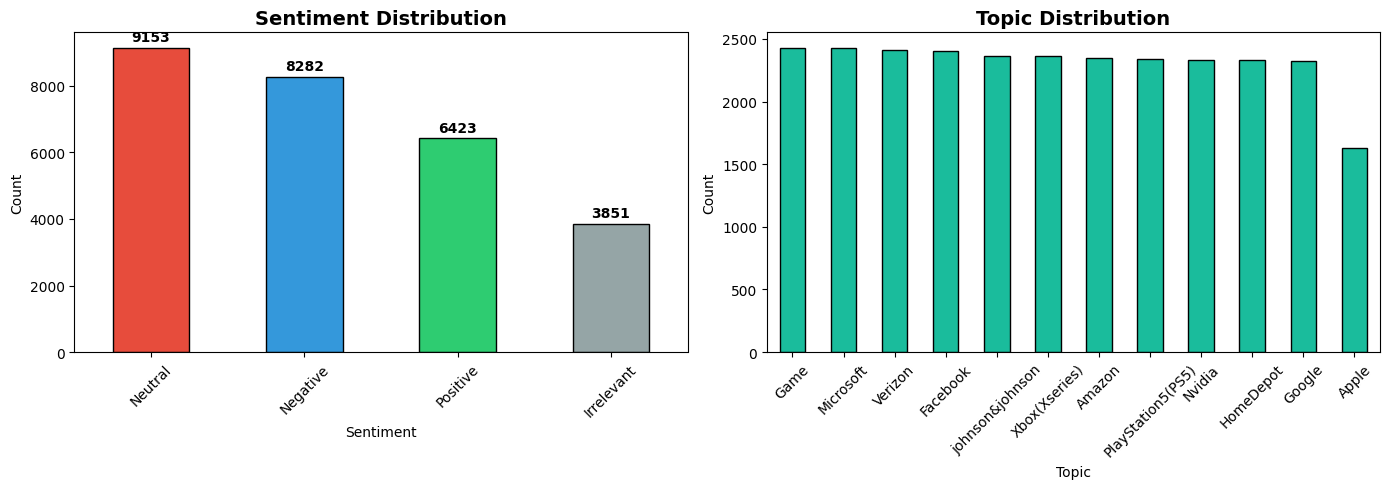

Saved: eda_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment bar chart
colors_sent = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']
ax1 = axes[0]
df['sentiment'].value_counts().plot(kind='bar', ax=ax1, color=colors_sent, edgecolor='black')
ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Sentiment')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
for i, (val, count) in enumerate(df['sentiment'].value_counts().items()):
    ax1.text(i, count + 200, str(count), ha='center', fontweight='bold')

# Topic bar chart
ax2 = axes[1]
df['topic'].value_counts().plot(kind='bar', ax=ax2, color='#1abc9c', edgecolor='black')
ax2.set_title('Topic Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Topic')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_distribution.png")

---
## 🧹 Step 2: Preprocessing

### 2.1 Filter: Keep only Positive / Neutral / Negative

In [8]:
print(f"Before filtering: {len(df)} rows")
df = df[df['sentiment'].isin(['Positive', 'Neutral', 'Negative'])].copy()
print(f"After removing 'Irrelevant': {len(df)} rows")

# --- Drop nulls in text/sentiment ---
df.dropna(subset=['text', 'sentiment'], inplace=True)
print(f"After dropping nulls: {len(df)} rows")

Before filtering: 27709 rows
After removing 'Irrelevant': 23858 rows
After dropping nulls: 23660 rows


### 2.2 Text Cleaning Function

In [9]:
def clean_text(text):
    """Clean tweet text for model input."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#\w+', '', text)                     # Remove #hashtags
    try:
        text = contractions.fix(text)                     # Expand contractions
    except Exception:
        pass
    text = re.sub(r'[^a-zA-Z\s]', '', text)              # Keep letters & spaces only
    text = re.sub(r'\s+', ' ', text).strip()              # Strip extra whitespace
    return text

# Apply cleaning
df['clean_text'] = df['text'].apply(clean_text)

# Remove rows where cleaning resulted in empty string
df = df[df['clean_text'].str.len() > 0].copy()
print(f"After text cleaning: {len(df)} rows")
print(f"\nSample cleaned text:")
print(df[['text', 'clean_text']].head(3).to_string())

After text cleaning: 23548 rows

Sample cleaned text:
             text  clean_text
0  @amazon wtf .          wtf
1   @ amazon wtf.  amazon wtf
2   @ amazon wtf.  amazon wtf


### 2.3 Label Encoding

In [10]:
sentiment_encoder = LabelEncoder()
df['sentiment_encoded'] = sentiment_encoder.fit_transform(df['sentiment'])
print(f"\nSentiment classes: {sentiment_encoder.classes_.tolist()}")
print(f"Encoded mapping: {dict(zip(sentiment_encoder.classes_, sentiment_encoder.transform(sentiment_encoder.classes_)))}")

topic_encoder = LabelEncoder()
df['topic_encoded'] = topic_encoder.fit_transform(df['topic'])
print(f"\nTopic classes ({len(topic_encoder.classes_)}): {topic_encoder.classes_.tolist()}")


Sentiment classes: ['Negative', 'Neutral', 'Positive']
Encoded mapping: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}

Topic classes (12): ['Amazon', 'Apple', 'Facebook', 'Game', 'Google', 'HomeDepot', 'Microsoft', 'Nvidia', 'PlayStation5(PS5)', 'Verizon', 'Xbox(Xseries)', 'johnson&johnson']


### 2.4 Train / Val / Test Split (70 / 15 / 15)

In [11]:
X_text = df['clean_text'].values
y_sentiment = df['sentiment_encoded'].values
topic_ids = df['topic_encoded'].values

# First split: 70% train, 30% temp
X_train_text, X_temp_text, y_train, y_temp, topic_train, topic_temp = train_test_split(
    X_text, y_sentiment, topic_ids,
    test_size=0.30, stratify=y_sentiment, random_state=SEED
)

# Second split: 50/50 of temp → 15% val, 15% test
X_val_text, X_test_text, y_val, y_test, topic_val, topic_test = train_test_split(
    X_temp_text, y_temp, topic_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

### 2.5 Split Summary

In [12]:
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"\n{name} set: {len(y_split)} samples")
    for cls_idx, cls_name in enumerate(sentiment_encoder.classes_):
        count = (y_split == cls_idx).sum()
        print(f"  {cls_name}: {count} ({count/len(y_split)*100:.1f}%)")


Train set: 16483 samples
  Negative: 5735 (34.8%)
  Neutral: 6302 (38.2%)
  Positive: 4446 (27.0%)

Val set: 3532 samples
  Negative: 1229 (34.8%)
  Neutral: 1350 (38.2%)
  Positive: 953 (27.0%)

Test set: 3533 samples
  Negative: 1229 (34.8%)
  Neutral: 1351 (38.2%)
  Positive: 953 (27.0%)


---
## 🤖 Step 3: RoBERTa Embedding Extraction & TensorFlow Dataset

### 3.1 Load RoBERTa Tokenizer & Model (PyTorch)

In [13]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
roberta_model = AutoModel.from_pretrained(MODEL_NAME)
roberta_model.to(DEVICE)
roberta_model.eval()  # Inference mode — no gradient needed
print(f"Loaded PyTorch model: {MODEL_NAME}")
print(f"Model on device: {next(roberta_model.parameters()).device}")

Loaded PyTorch model: cardiffnlp/twitter-roberta-base-sentiment-latest
Model on device: cpu


### 3.2 Mean Pooling & Batch Extraction Function

In [14]:
MAX_LEN = 128
EMBED_BATCH_SIZE = 64  # Batch size for embedding extraction (no gradients → can be larger)

def mean_pooling(last_hidden_state, attention_mask):
    """
    Mean pooling: average all token embeddings weighted by attention_mask.
    Much better than [CLS]-only — captures full sentence context.
    """
    # attention_mask: (batch, seq_len) → expand to (batch, seq_len, hidden_dim)
    mask_expanded = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    sum_embeddings = torch.sum(last_hidden_state * mask_expanded, dim=1)
    sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask

def extract_embeddings(texts, batch_size=EMBED_BATCH_SIZE):
    """
    Extract mean-pooled embeddings from RoBERTa using PyTorch.
    Returns numpy array of shape (N, 768).
    """
    all_embeddings = []
    total = len(texts)

    for i in range(0, total, batch_size):
        batch_texts = texts[i:i+batch_size].tolist()

        # Tokenize batch
        encoding = tokenizer(
            batch_texts,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Move to GPU if available
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)

        # Forward pass — no gradients needed for feature extraction
        with torch.no_grad():
            outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling over all tokens (weighted by attention mask)
        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()
        all_embeddings.append(embeddings)

        if (i // batch_size) % 20 == 0:
            print(f"  Processed {min(i+batch_size, total)}/{total} texts...")

    return np.concatenate(all_embeddings, axis=0)

### 3.3 Extract Embeddings for All Splits

In [15]:
print("\n--- Extracting Train embeddings (mean pooling) ---")
train_embeddings = extract_embeddings(X_train_text)
print(f"Train embeddings shape: {train_embeddings.shape}")

print("\n--- Extracting Val embeddings (mean pooling) ---")
val_embeddings = extract_embeddings(X_val_text)
print(f"Val embeddings shape: {val_embeddings.shape}")

print("\n--- Extracting Test embeddings (mean pooling) ---")
test_embeddings = extract_embeddings(X_test_text)
print(f"Test embeddings shape: {test_embeddings.shape}")

# Free GPU memory after extraction
del roberta_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("\n Embeddings extracted! RoBERTa model freed from GPU.")


--- Extracting Train embeddings (mean pooling) ---
  Processed 64/16483 texts...
  Processed 1344/16483 texts...
  Processed 2624/16483 texts...
  Processed 3904/16483 texts...
  Processed 5184/16483 texts...
  Processed 6464/16483 texts...
  Processed 7744/16483 texts...
  Processed 9024/16483 texts...
  Processed 10304/16483 texts...
  Processed 11584/16483 texts...
  Processed 12864/16483 texts...
  Processed 14144/16483 texts...
  Processed 15424/16483 texts...
Train embeddings shape: (16483, 768)

--- Extracting Val embeddings (mean pooling) ---
  Processed 64/3532 texts...
  Processed 1344/3532 texts...
  Processed 2624/3532 texts...
Val embeddings shape: (3532, 768)

--- Extracting Test embeddings (mean pooling) ---
  Processed 64/3533 texts...
  Processed 1344/3533 texts...
  Processed 2624/3533 texts...
Test embeddings shape: (3533, 768)

 Embeddings extracted! RoBERTa model freed from GPU.


### 3.4 Create TensorFlow Datasets

In [16]:
BATCH_TRAIN = 16
BATCH_EVAL = 32
BUFFER_SIZE = 1000

def make_tf_dataset(embeddings, topic_ids, labels, batch_size, shuffle=False):
    """Create a tf.data.Dataset with pre-extracted embeddings + topic input."""
    dataset = tf.data.Dataset.from_tensor_slices((
        {
            'text_embedding': embeddings.astype(np.float32),
            'topic_id': topic_ids.reshape(-1, 1)
        },
        labels
    ))
    if shuffle:
        dataset = dataset.shuffle(buffer_size=BUFFER_SIZE, seed=SEED)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = make_tf_dataset(train_embeddings, topic_train, y_train, BATCH_TRAIN, shuffle=True)
val_ds   = make_tf_dataset(val_embeddings, topic_val, y_val, BATCH_EVAL)
test_ds  = make_tf_dataset(test_embeddings, topic_test, y_test, BATCH_EVAL)

# Quick check
for batch_x, batch_y in train_ds.take(1):
    print(f"Batch text_embedding shape: {batch_x['text_embedding'].shape}")
    print(f"Batch topic_id shape: {batch_x['topic_id'].shape}")
    print(f"Batch labels shape: {batch_y.shape}")
    break

print("\n TF Datasets created successfully!")

Batch text_embedding shape: (16, 768)
Batch topic_id shape: (16, 1)
Batch labels shape: (16,)

 TF Datasets created successfully!


---
## 🏗️ Step 4: Model Architecture

In [17]:
NUM_TOPICS = len(topic_encoder.classes_)  # 12 topics
NUM_CLASSES = len(sentiment_encoder.classes_)  # 3 classes
ROBERTA_DIM = 768  # [CLS] embedding dimension
TOPIC_EMB_DIM = 32
DROPOUT_RATE = 0.4

def build_model(roberta_dim=768, num_topics=12, num_classes=3,
                topic_emb_dim=32, dropout_rate=0.4):
    """
    Improved classification head with BatchNorm + deeper architecture:
    - Text branch: RoBERTa mean-pooled embedding (768-dim) → BatchNorm → Dropout
    - Topic branch: Embedding(num_topics+1, 32) → Flatten
    - Fusion: Concatenate → Dense(512) → BN → Dropout → Dense(256) → BN → Dropout → Dense(64) → Softmax
    """
    # --- Inputs ---
    text_embedding = tf.keras.Input(shape=(roberta_dim,), dtype=tf.float32, name='text_embedding')
    topic_id       = tf.keras.Input(shape=(1,),           dtype=tf.int32,   name='topic_id')

    # --- Text branch: normalize embeddings first ---
    text_vec = tf.keras.layers.BatchNormalization(name='text_bn')(text_embedding)
    text_vec = tf.keras.layers.Dropout(dropout_rate, name='text_dropout')(text_vec)

    # --- Topic branch ---
    topic_vec = tf.keras.layers.Embedding(
        input_dim=num_topics + 1,
        output_dim=topic_emb_dim,
        name='topic_embedding'
    )(topic_id)
    topic_vec = tf.keras.layers.Flatten(name='topic_flatten')(topic_vec)

    # --- Fusion: deeper head with BatchNorm for better gradient flow ---
    combined = tf.keras.layers.Concatenate(name='fusion')([text_vec, topic_vec])
    x = tf.keras.layers.Dense(512, activation='relu', name='dense_512')(combined)
    x = tf.keras.layers.BatchNormalization(name='bn_512')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_512')(x)
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256')(x)
    x = tf.keras.layers.Concatenate(name='skip_connection')([x, combined])  # skip connection
    x = tf.keras.layers.Dense(256, activation='relu', name='dense_256b')(x)
    x = tf.keras.layers.BatchNormalization(name='bn_256')(x)
    x = tf.keras.layers.Dropout(dropout_rate, name='dropout_256')(x)
    x = tf.keras.layers.Dense(64, activation='relu', name='dense_64')(x)
    output = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = tf.keras.Model(
        inputs=[text_embedding, topic_id],
        outputs=output,
        name='RoBERTa_Topic_Sentiment'
    )
    return model

### Compile Model

- **Optimizer:** AdamW (lr=1e-3, weight_decay=0.01) — higher LR since we're training a head on frozen embeddings
- **Loss:** SparseCategoricalCrossentropy
- **Label Smoothing:** 0.1 for better generalization

In [18]:
model = build_model(ROBERTA_DIM, NUM_TOPICS, NUM_CLASSES, TOPIC_EMB_DIM, DROPOUT_RATE)

# Compile
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=0.01)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

---
## 🏋️ Step 5: Training

Train the classification head with:
- **Class weights** to handle imbalanced data
- **EarlyStopping** (patience=5) to prevent overfitting
- **ReduceLROnPlateau** for adaptive learning rate
- **ModelCheckpoint** to save best weights

### 5.1 Compute Class Weights

In [19]:
class_weights_arr = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"Class weights: {class_weight_dict}")
for idx, name in enumerate(sentiment_encoder.classes_):
    print(f"  {name} (class {idx}): weight = {class_weight_dict[idx]:.4f}")

Class weights: {0: np.float64(0.9580354548096484), 1: np.float64(0.8718396276314397), 2: np.float64(1.235792472634578)}
  Negative (class 0): weight = 0.9580
  Neutral (class 1): weight = 0.8718
  Positive (class 2): weight = 1.2358


### 5.2 Setup Callbacks

In [20]:
os.makedirs('./best_model/', exist_ok=True)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1,
        min_lr=1e-6
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./best_model/model.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )
]

### 5.3 Train the Model

In [21]:
EPOCHS = 30  # EarlyStopping will halt when needed

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

Epoch 1/30
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6055 - loss: 0.9322
Epoch 1: val_loss improved from None to 0.68147, saving model to ./best_model/model.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6337 - loss: 0.8524 - val_accuracy: 0.7058 - val_loss: 0.6815 - learning_rate: 0.0010
Epoch 2/30
1030/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6717 - loss: 0.7597
Epoch 2: val_loss improved from 0.68147 to 0.65552, saving model to ./best_model/model.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.6783 - loss: 0.7467 - val_accuracy: 0.7206 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 3/30
1030/1031 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6902 - loss: 0.7238
Epoch 3: val_loss improved from 0.65552 to 0.62322, saving model to ./best_model/model.weights.h5
1031/1031 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.6920 - loss: 0.7123 - val_accuracy: 0.7367 - val_loss: 0.6232 - learning_rate: 0.0010
Epoch 4/3

---
## 📈 Step 6: Evaluation

### 6.1 Load Best Weights & Predict

In [22]:

model.load_weights('./best_model/model.weights.h5')
print("Loaded best model weights.")

# Predict on test set
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

Loaded best model weights.
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


### 6.2 Classification Report

In [23]:
target_names = sentiment_encoder.classes_.tolist()
print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

overall_acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Macro F1-Score:   {macro_f1:.4f}")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative     0.9013    0.8544    0.8772      1229
     Neutral     0.8735    0.8534    0.8633      1351
    Positive     0.7872    0.8657    0.8246       953

    accuracy                         0.8571      3533
   macro avg     0.8540    0.8578    0.8550      3533
weighted avg     0.8599    0.8571    0.8577      3533

Overall Accuracy: 0.8571
Macro F1-Score:   0.8550


### 6.3 Confusion Matrix

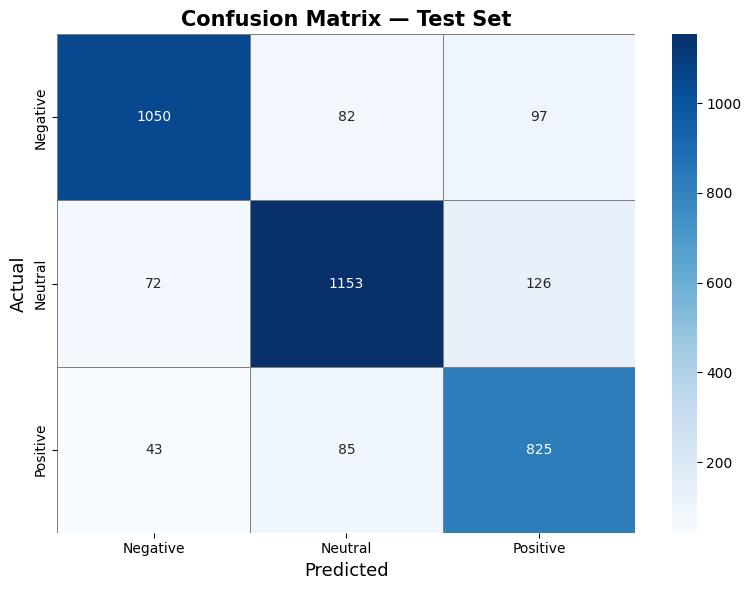

Saved: lose_figure/confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=target_names, yticklabels=target_names,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Confusion Matrix — Test Set', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('loss_figure/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_figure/confusion_matrix.png")

### 6.4 Training History (Loss & Accuracy Curves)

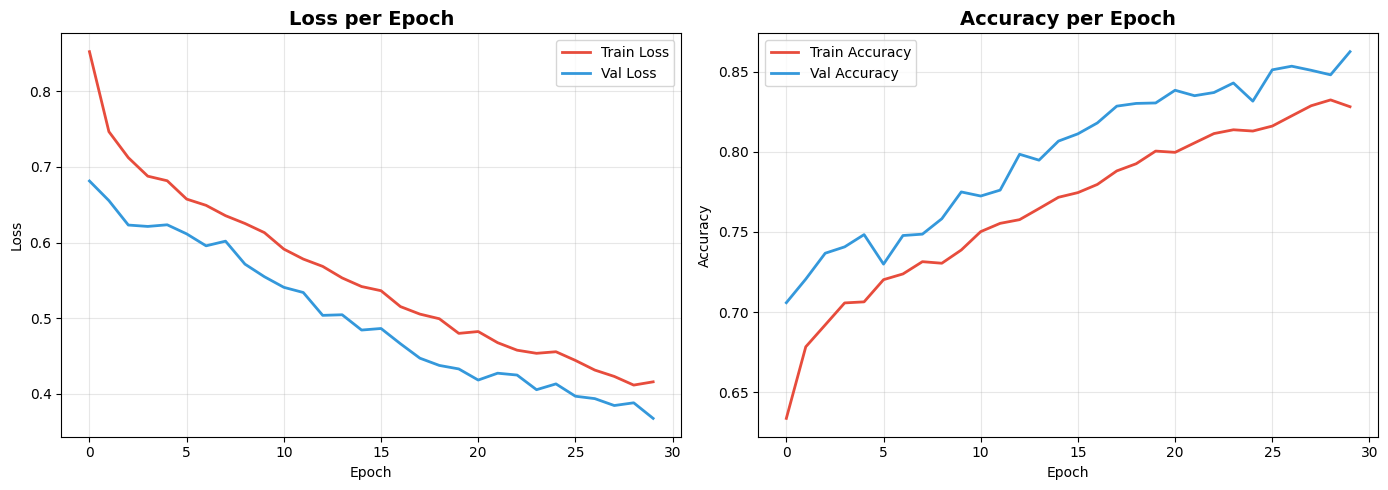

Saved: lose_figure/training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#e74c3c')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#3498db')
axes[0].set_title('Loss per Epoch', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#e74c3c')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#3498db')
axes[1].set_title('Accuracy per Epoch', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_figure/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: loss_figure/training_history.png")

---
## 🔮 Step 7: Inference Demo

Reload the RoBERTa model and test with sample COVID-19 related tweets.

In [26]:
# Reload RoBERTa for inference (lightweight — only needed for single predictions)
roberta_inference = AutoModel.from_pretrained(MODEL_NAME)
roberta_inference.to(DEVICE)
roberta_inference.eval()

def predict_sentiment(text, topic_str):
    """
    Predict sentiment for a single tweet.

    Args:
        text (str): Tweet content
        topic_str (str): Topic name (must be in training set topics)

    Returns:
        dict: {'sentiment': str, 'confidence': float, 'probabilities': dict}
    """
    # Clean the input text
    cleaned = clean_text(text)

    # Encode topic
    try:
        topic_id = topic_encoder.transform([topic_str])[0]
    except ValueError:
        print(f"  Unknown topic '{topic_str}'. Using index 0 as fallback.")
        topic_id = 0

    # Tokenize & extract embedding with PyTorch
    encoding = tokenizer(
        cleaned,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(DEVICE)
    attention_mask = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = roberta_inference(input_ids=input_ids, attention_mask=attention_mask)
    # Use same mean pooling as training
    embedding = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()  # (1, 768)

    # Predict with Keras model
    inputs = {
        'text_embedding': embedding.astype(np.float32),
        'topic_id': np.array([[topic_id]], dtype=np.int32)
    }

    probs = model.predict(inputs, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = sentiment_encoder.inverse_transform([pred_idx])[0]

    # Build probabilities dict
    prob_dict = {
        sentiment_encoder.classes_[i]: float(probs[i])
        for i in range(len(sentiment_encoder.classes_))
    }

    return {
        'sentiment': pred_label,
        'confidence': float(probs[pred_idx]),
        'probabilities': prob_dict
    }

### 🧪 Test Examples

In [31]:
test_examples = [
    ("Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends", "Game"),
]

print("=" * 70)
print("Test examples")
print("=" * 70)

for i, (text, topic) in enumerate(test_examples, 1):
    result = predict_sentiment(text, topic)
    print(f"\n--- Example {i} ---")
    print(f"  Text:       {text}")
    print(f"  Topic:      {topic}")
    print(f"  Prediction: {result['sentiment']} (confidence: {result['confidence']:.4f})")
    print(f"  Probs:      {', '.join(f'{k}: {v:.4f}' for k, v in result['probabilities'].items())}")

print("\n Pipeline complete!")

Test examples

--- Example 1 ---
  Text:       Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Topic:      Game
  Prediction: Negative (confidence: 0.9170)
  Probs:      Negative: 0.9170, Neutral: 0.0266, Positive: 0.0564

 Pipeline complete!


---
## 🔍 Step 8: LIME-based Token Attribution

In [32]:
# --- 8.1 LIME-compatible prediction wrapper ---
from lime.lime_text import LimeTextExplainer

def make_lime_predict_fn(topic_str):
    """
    Factory: returns a LIME-compatible predict function for a given topic.
    
    The returned function: list[str] → np.ndarray of shape (N, 3) probabilities.
    It re-embeds each perturbed text through the full pipeline.
    """
    # Encode topic once
    try:
        tid = topic_encoder.transform([topic_str])[0]
    except ValueError:
        tid = 0

    def predict_fn(texts):
        # Clean all texts
        cleaned = [clean_text(t) for t in texts]
        # Handle empty strings after cleaning
        cleaned = [t if len(t) > 0 else "empty" for t in cleaned]
        
        # Tokenize batch with RoBERTa
        encoding = tokenizer(
            cleaned,
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids = encoding['input_ids'].to(DEVICE)
        attention_mask = encoding['attention_mask'].to(DEVICE)
        
        # Extract mean-pooled embeddings
        with torch.no_grad():
            outputs = roberta_inference(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = mean_pooling(outputs.last_hidden_state, attention_mask).cpu().numpy()
        
        # Predict with Keras model
        batch_size = len(texts)
        inputs = {
            'text_embedding': embeddings.astype(np.float32),
            'topic_id': np.full((batch_size, 1), tid, dtype=np.int32)
        }
        probs = model.predict(inputs, verbose=0)
        return probs

    return predict_fn

# Initialize LIME explainer
lime_explainer = LimeTextExplainer(
    class_names=sentiment_encoder.classes_.tolist(),
    split_expression=r'\W+',
    random_state=SEED
)

print("✅ LIME explainer and wrapper ready.")

✅ LIME explainer and wrapper ready.


### 8.2 LIME Demo — Explain Individual Predictions


LIME Example 1
  Tweet: Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Topic: Game
  Predicted: Negative (confidence: 0.9170)
  Probabilities: Negative: 0.9170, Neutral: 0.0266, Positive: 0.0564

  Top POSITIVE influence words (push toward 'Negative'):
    'champion': +0.0180
    '50': +0.0115

  Top NEGATIVE influence words (push away from 'Negative'):
    'ruining': -0.0457
    'crashing': -0.0405
    'Another': -0.0335
    'Im': -0.0303
    'done': -0.0279


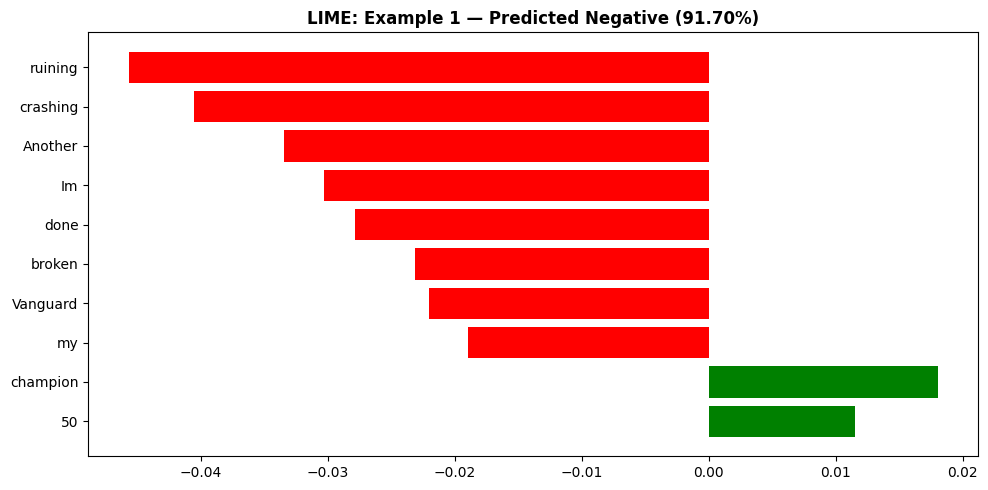


✅ LIME analysis complete for 1 tweets.


In [33]:
# --- 8.2 Run LIME on demo tweets ---
lime_demo_tweets = [
    ("Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends", "Game"),
]

lime_results = []  # Store for Steps 9-11

for i, (tweet, topic) in enumerate(lime_demo_tweets, 1):
    print(f"\n{'='*70}")
    print(f"LIME Example {i}")
    print(f"{'='*70}")
    print(f"  Tweet: {tweet}")
    print(f"  Topic: {topic}")
    
    # Get baseline prediction
    baseline = predict_sentiment(tweet, topic)
    pred_label = baseline['sentiment']
    pred_conf = baseline['confidence']
    print(f"  Predicted: {pred_label} (confidence: {pred_conf:.4f})")
    print(f"  Probabilities: {', '.join(f'{k}: {v:.4f}' for k,v in baseline['probabilities'].items())}")
    
    # Run LIME
    predict_fn = make_lime_predict_fn(topic)
    explanation = lime_explainer.explain_instance(
        tweet, predict_fn,
        num_features=10,
        num_samples=500
    )
    
    # Extract top words
    word_weights = explanation.as_list()
    positive_words = [(w, wt) for w, wt in word_weights if wt > 0]
    negative_words = [(w, wt) for w, wt in word_weights if wt < 0]
    
    print(f"\n  Top POSITIVE influence words (push toward '{pred_label}'):")
    for w, wt in positive_words[:5]:
        print(f"    '{w}': {wt:+.4f}")
    
    print(f"\n  Top NEGATIVE influence words (push away from '{pred_label}'):")
    for w, wt in negative_words[:5]:
        print(f"    '{w}': {wt:+.4f}")
    
    # Store result for later steps
    lime_results.append({
        'tweet': tweet,
        'topic': topic,
        'prediction': baseline,
        'positive_words': positive_words,
        'negative_words': negative_words,
        'explanation': explanation,
    })
    
    # Visualize
    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(10, 5)
    plt.title(f"LIME: Example {i} — Predicted {pred_label} ({pred_conf:.2%})", fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'lime_figure/lime_step8_example_{i}.png', dpi=150, bbox_inches='tight')
    plt.show()

print(f"\n✅ LIME analysis complete for {len(lime_demo_tweets)} tweets.")


---
## 🔄 Step 9: Counterfactual Generation


In [ ]:
# --- 9.1 Configure Groq API ---
import requests, json, time
API_key = input("Please enter your Groq API key: ").strip()
GROQ_API_KEY = API_key
GROQ_MODEL   = "llama-3.1-8b-instant"      
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

def call_llm(prompt, timeout=60):
    headers = {
        "Authorization": f"Bearer {GROQ_API_KEY}",
        "Content-Type":  "application/json",
    }
    payload = {
        "model":       GROQ_MODEL,
        "messages":    [{"role": "user", "content": prompt}],
        "stream":      False,
        "temperature": 0.7,
    }
    r = requests.post(GROQ_URL, headers=headers, json=payload, timeout=timeout)
    if not r.ok:
        print(f"  ❌ HTTP {r.status_code}: {r.text}")   # in ra chi tiết lỗi
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"].strip()

# Test + liệt kê models có sẵn
try:
    # Lấy danh sách models
    r = requests.get(
        "https://api.groq.com/openai/v1/models",
        headers={"Authorization": f"Bearer {GROQ_API_KEY}"}
    )
    models = [m["id"] for m in r.json().get("data", [])]
    print("Models available on your account:")
    for m in models:
        print(f"  - {m}")
except Exception as e:
    print(f"Could not list models: {e}")

# Test call
try:
    test = call_llm("Say OK only.", timeout=15)
    print(f"\n✅ Groq API ready! Model: {GROQ_MODEL}")
    print(f"   Test: {test}")
except Exception as e:
    print(f"⚠️ Failed: {e}")
# --- 9.2 Generate Counterfactual with Groq ---
counterfactuals = []

result     = lime_results[0]
tweet      = result['tweet']
topic      = result['topic']
pred       = result['prediction']
pred_label = pred['sentiment']

if pred_label == 'Negative':   target_sentiment = 'Positive'
elif pred_label == 'Positive': target_sentiment = 'Negative'
else:                          target_sentiment = 'Positive'

pos_words_str = ", ".join([f"'{w}' ({wt:+.4f})" for w, wt in result['positive_words'][:5]])
neg_words_str = ", ".join([f"'{w}' ({wt:+.4f})" for w, wt in result['negative_words'][:5]])

print(f"\n{'='*70}")
print(f"Groq Counterfactual Generation")
print(f"{'='*70}")
print(f"  Original ({pred_label}, conf: {pred['confidence']:.4f}):\n    {tweet}")
print(f"  Words TOWARD '{pred_label}': {pos_words_str}")
print(f"  Words AWAY from '{pred_label}': {neg_words_str}")

prompt = f"""You are a sentiment analysis assistant. Rewrite the following tweet to change its sentiment from {pred_label} to {target_sentiment}.

Original Tweet: "{tweet}"
Target Sentiment: {target_sentiment}

LIME analysis:
- Words pushing TOWARD current sentiment: {pos_words_str}
- Words pushing AWAY from current sentiment: {neg_words_str}

Modify the minimum number of words (focus on the TOWARD words) to flip sentiment to {target_sentiment}.
Return ONLY the rewritten tweet. No explanations, no quotes, no extra text."""

cf_text = tweet
api_status = "failed"

for attempt in range(1, 4):
    try:
        cf_text = call_llm(prompt, timeout=60)
        for q in ['"', "'"]:
            if cf_text.startswith(q) and cf_text.endswith(q):
                cf_text = cf_text[1:-1]
        api_status = "success"
        print(f"\n  Counterfactual:\n    {cf_text}")
        break
    except Exception as e:
        print(f"  Attempt {attempt} failed: {e}")
        if attempt < 3:
            time.sleep(5)
        else:
            print(" Falling back to original tweet.")

counterfactuals.append({
    'original': tweet, 'counterfactual': cf_text,
    'topic': topic, 'original_prediction': pred,
    'target_sentiment': target_sentiment, 'attack_status': api_status,
    'lime_positive_words': result['positive_words'],
    'lime_negative_words': result['negative_words'],
})
# --- 10.1 Re-predict and compare ---

def compare_predictions(original_text, counterfactual_text, topic_str, original_pred):
    """Compare predictions between original and counterfactual tweets."""
    cf_pred = predict_sentiment(counterfactual_text, topic_str)

    # Probability deltas
    deltas = {}
    for cls in original_pred['probabilities']:
        deltas[cls] = cf_pred['probabilities'][cls] - original_pred['probabilities'][cls]

    # Word-level diff
    orig_words = set(original_text.lower().split())
    cf_words   = set(counterfactual_text.lower().split())

    return {
        'counterfactual_prediction': cf_pred,
        'deltas': deltas,
        'words_removed': orig_words - cf_words,
        'words_added':   cf_words - orig_words,
        'flipped': original_pred['sentiment'] != cf_pred['sentiment'],
    }

# Run comparisons
print("=" * 80)
print("SIDE-BY-SIDE COMPARISON: Original vs. Counterfactual")
print("=" * 80)

comparison_results = []

for i, cf in enumerate(counterfactuals, 1):
    comp = compare_predictions(
        cf['original'], cf['counterfactual'], cf['topic'], cf['original_prediction']
    )
    comparison_results.append(comp)

    orig_pred = cf['original_prediction']
    cf_pred   = comp['counterfactual_prediction']

    print(f"\n{'-'*80}")
    print(f"Example {i}  [status: {cf['attack_status']}]")
    print(f"{'-'*80}")
    print(f"  Original:       {cf['original']}")
    print(f"  Counterfactual: {cf['counterfactual']}")
    print()
    print(f"  Original prediction:      {orig_pred['sentiment']} ({orig_pred['confidence']:.4f})")
    print(f"  Counterfactual prediction: {cf_pred['sentiment']} ({cf_pred['confidence']:.4f})")
    print(f"  Sentiment flipped: {'✅ YES' if comp['flipped'] else '❌ NO'}")
    print()
    print(f"  Probability deltas:")
    for cls, delta in comp['deltas'].items():
        arrow = "▲" if delta > 0 else "▼" if delta < 0 else "─"
        print(f'    {cls}: {delta:+.4f} {arrow}')
    print()
    print(f"  Words Removed: {comp['words_removed']}")
    print(f"  Words Added:   {comp['words_added']}")

print(f"\n✅ Comparison complete.")
# --- 11.1 Generate full explanations ---

def format_explanation(lime_result, counterfactual, comparison):
    """Format a complete human-readable explanation."""
    orig = lime_result['tweet']
    pred = lime_result['prediction']['sentiment']
    conf = lime_result['prediction']['confidence']
    cf_text = counterfactual['counterfactual']
    cf_pred = comparison['counterfactual_prediction']['sentiment']
    cf_conf = comparison['counterfactual_prediction']['confidence']

    # LIME top words
    pos_words = [f"'{w}' ({wt:+.4f})" for w, wt in lime_result['positive_words'][:3]]
    neg_words = [f"'{w}' ({wt:+.4f})" for w, wt in lime_result['negative_words'][:3]]

    lines = []
    lines.append(f"📌 EXPLANATION")
    lines.append(f"")
    lines.append(f"The model predicted **{pred}** (confidence: {conf:.1%}) for:")
    lines.append(f'  \\"{orig}\"')
    lines.append(f"")
    lines.append(f"🔍 LIME — Words pushing TOWARD '{pred}': {', '.join(pos_words)}")
    lines.append(f"🔍 LIME — Words pushing AWAY from '{pred}': {', '.join(neg_words)}")
    lines.append(f"")
    lines.append(f"🤖 Ollama Counterfactual Generation:")
    lines.append(f"   Status: {counterfactual['attack_status']}")
    lines.append(f"")
    if comparison['flipped']:
        lines.append(f"✅ By modifying the tweet, the sentiment flips to **{cf_pred}** "
                      f"(confidence: {cf_conf:.1%}).")
    else:
        lines.append(f"❌ After modification, the model still predicts "
                      f"**{cf_pred}** (confidence: {cf_conf:.1%}) — the sentiment "
                      f"did not flip.")
    lines.append(f"")
    lines.append(f"Counterfactual tweet:")
    lines.append(f'  \\"{cf_text}\"')

    return "\n".join(lines)

# Print all explanations
print("=" * 80)
print("FULL EXPLANATIONS — Steps 8–11 Combined (LIME + Ollama)")
print("=" * 80)

for i in range(len(counterfactuals)):
    print(f"\n{'━'*80}")
    print(f"  Tweet {i+1}")
    print(f"{'_'*80}")
    expl = format_explanation(lime_results[i], counterfactuals[i], comparison_results[i])
    print(expl)

print(f"\n Full explanations generated for all examples.")

Models available on your account:
  - llama-3.1-8b-instant
  - groq/compound-mini
  - canopylabs/orpheus-arabic-saudi
  - meta-llama/llama-4-scout-17b-16e-instruct
  - llama-3.3-70b-versatile
  - meta-llama/llama-prompt-guard-2-86m
  - qwen/qwen3.6-27b
  - meta-llama/llama-prompt-guard-2-22m
  - openai/gpt-oss-120b
  - groq/compound
  - qwen/qwen3-32b
  - openai/gpt-oss-safeguard-20b
  - allam-2-7b
  - canopylabs/orpheus-v1-english
  - whisper-large-v3
  - openai/gpt-oss-20b
  - whisper-large-v3-turbo

✅ Groq API ready! Model: llama-3.1-8b-instant
   Test: OK

Groq Counterfactual Generation
  Original (Negative, conf: 0.9170):
    Another patch, another broken champion ruining ranked. The balance team actually has no idea what they are doing. Vanguard keeps crashing my PC and cost me 50 LP today. Im so done with this game 🤬 #LeagueOfLegends
  Words TOWARD 'Negative': 'champion' (+0.0180), '50' (+0.0115)
  Words AWAY from 'Negative': 'ruining' (-0.0457), 'crashing' (-0.0405), 'Another' 